In [33]:
import xarray as xr
import numpy as np
import healpy as hp
import xeofs as xe
from matplotlib import pyplot as plt
import matplotlib as mpl
import os
import pickle
from pathlib import Path
DATA_DIR = "./processed_data"
figure_save_path = "./figures/wa_xeofs/"

In [34]:
# 处理陆地-海洋掩膜

if os.path.exists(os.path.join(DATA_DIR, "ocean_mask_2deg.nc")):
    print("="*70)
    print("✅ 发现已保存的海洋掩膜数据")
    print("   正在加载...")
    ocean_mask = xr.open_dataarray(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))
    print(f"   加载完成! 形状: {ocean_mask.shape}")

def _ocean(ds):
    fraction = xr.open_dataarray(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))
    return fraction == 1

✅ 发现已保存的海洋掩膜数据
   正在加载...
   加载完成! 形状: (15, 180)


In [35]:
# 1. 加载 zg 数据（位势高度，单位：m）
print("读取 zg 数据...")
zg_cntl = xr.open_dataset('processed_data/zg_2deg_interp_cntl.nc')['zg']
zg_p4k = xr.open_dataset('processed_data/zg_2deg_interp_p4k.nc')['zg']
zg_4co2 = xr.open_dataset('processed_data/zg_2deg_interp_4co2.nc')['zg']

# 2. 应用海洋 mask（与之前相同的 ocean_mask）
zg_cntl_ocean = zg_cntl.where(ocean_mask)
zg_p4k_ocean = zg_p4k.where(ocean_mask)
zg_4co2_ocean = zg_4co2.where(ocean_mask)

# 3. 计算海洋平均高度（对每一层）
# zg 不随时间变化，所以只对空间平均
zg_cntl_mean = zg_cntl_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_p4k_mean = zg_p4k_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_4co2_mean = zg_4co2_ocean.mean(dim=['lat', 'lon'], skipna=True)

# 转换为 km 单位
zg_cntl_km = zg_cntl_mean / 1000.0
zg_p4k_km = zg_p4k_mean / 1000.0
zg_4co2_km = zg_4co2_mean / 1000.0

print(f"✓ zg 数据加载完成")
print(f"  高度范围: {zg_cntl_km.min().values:.2f} - {zg_cntl_km.max().values:.2f} km")
print(f"  层数: {len(zg_cntl_km)}")

读取 zg 数据...
✓ zg 数据加载完成
  高度范围: 0.01 - 22.86 km
  层数: 22


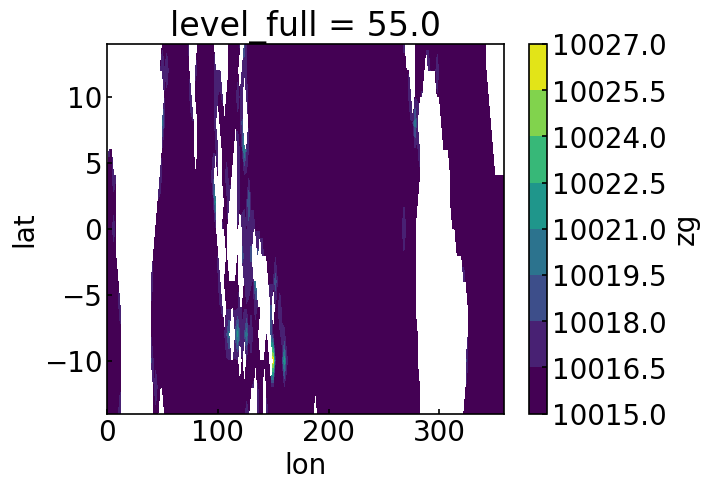

In [36]:
zg_cntl_ocean[6].plot.contourf()

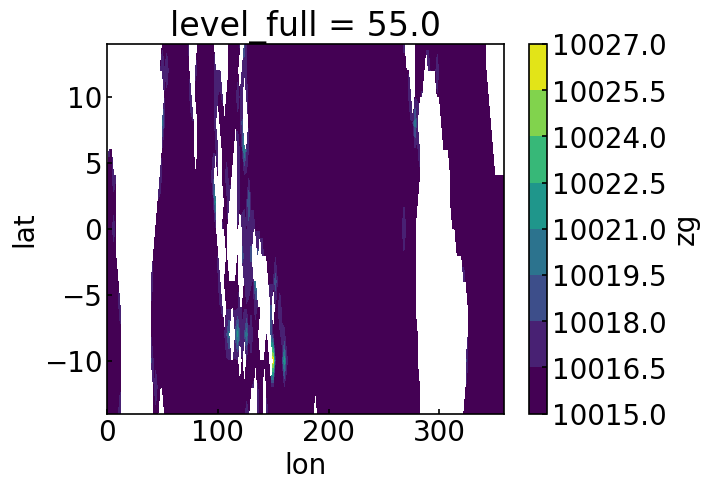

In [38]:
zg_p4k_ocean[6].plot.contourf()

In [ ]:
# 读取保存的EOF数据
print("正在加载EOF数据...")
with open('/work/mh1498/m301257/processed_data/eof_CNTL.pkl', 'rb') as f:
    eof_data_cntl = pickle.load(f)
    
with open('/work/mh1498/m301257/processed_data/eof_P4K.pkl', 'rb') as f:
    eof_data_p4k = pickle.load(f)
    
with open('/work/mh1498/m301257/processed_data/eof_4CO2.pkl', 'rb') as f:
    eof_data_4co2 = pickle.load(f)

# 提取EOFs和方差解释
eofs_cntl = eof_data_cntl['eofs']
var_cntl = eof_data_cntl['variance']

eofs_p4k = eof_data_p4k['eofs']
var_p4k = eof_data_p4k['variance']

eofs_4co2 = eof_data_4co2['eofs']
var_4co2 = eof_data_4co2['variance']

print(f"✓ EOF数据加载完成")
print(f"  CNTL - 模态数: {eofs_cntl.shape[0]}, 层数: {eofs_cntl.shape[1]}")
print(f"  P4K  - 模态数: {eofs_p4k.shape[0]}, 层数: {eofs_p4k.shape[1]}")
print(f"  4CO2 - 模态数: {eofs_4co2.shape[0]}, 层数: {eofs_4co2.shape[1]}")

# 对齐P4K和4CO2的EOF符号（相对于CNTL）
eofs_p4k_aligned = eofs_p4k.copy()
eofs_4co2_aligned = eofs_4co2.copy()

for mode_idx in range(2):
    # 检查与CNTL的相关性
    corr_p4k = np.corrcoef(eofs_cntl.isel(mode=mode_idx).values, 
                            eofs_p4k.isel(mode=mode_idx).values)[0, 1]
    if corr_p4k < 0:
        eofs_p4k_aligned[mode_idx, :] = -eofs_p4k_aligned[mode_idx, :]
        print(f"  模态 {mode_idx+1}: P4K符号已翻转 (相关性: {corr_p4k:.3f})")
    
    corr_4co2 = np.corrcoef(eofs_cntl.isel(mode=mode_idx).values, 
                             eofs_4co2.isel(mode=mode_idx).values)[0, 1]
    if corr_4co2 < 0:
        eofs_4co2_aligned[mode_idx, :] = -eofs_4co2_aligned[mode_idx, :]
        print(f"  模态 {mode_idx+1}: 4CO2符号已翻转 (相关性: {corr_4co2:.3f})")


正在加载EOF数据...
✓ EOF数据加载完成
  CNTL - 模态数: 2, 层数: 22
  P4K  - 模态数: 2, 层数: 22
  4CO2 - 模态数: 2, 层数: 22
✓ EOF数据加载完成
  CNTL - 模态数: 2, 层数: 22
  P4K  - 模态数: 2, 层数: 22
  4CO2 - 模态数: 2, 层数: 22


✅ Publication-quality figures saved:
   - ./figures/eof_vertical_comparison_publication.png (600 dpi)
   - ./figures/eof_vertical_comparison_publication.pdf


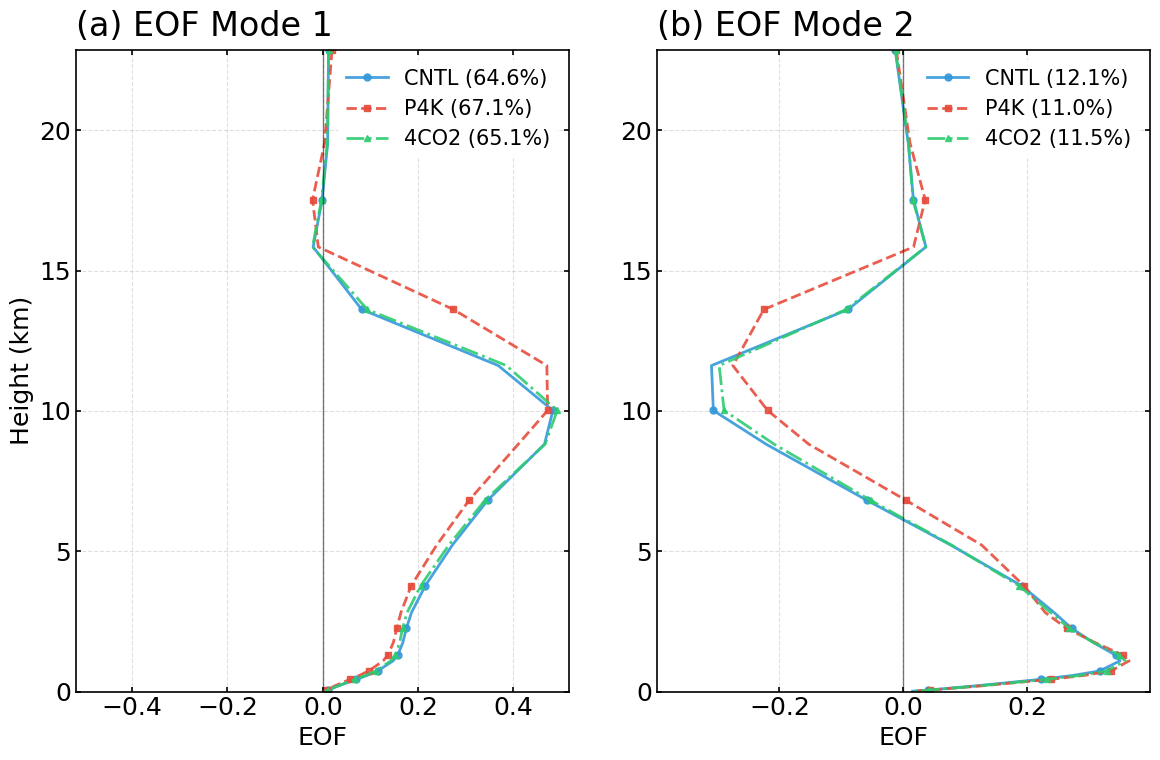

In [ ]:
# 比较不同实验的EOF垂直剖面 - 学术发表级别绘图
# 设置学术风格
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize']=20

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# 高级学术配色方案（Nature/Science风格，色盲友好）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 经典蓝、活力橙、自然绿
# 或者使用更现代的配色：
# colors = ['#4C72B0', '#DD8452', '#55A868']  # Seaborn深色调色板
# 或者使用高端学术期刊风格：
colors = ['#3498db', '#e74c3c', '#2ecc71']  # 现代鲜明配色
labels = ['CNTL', 'P4K', '4CO2']
markers = ['o', 's', '^']  # circle, square, triangle
linestyles = ['-', '--', '-.']

for mode_idx in range(2):
    ax = axes[mode_idx]
    
    # Plot CNTL
    eof_cntl = eofs_cntl.isel(mode=mode_idx)
    # 使用km作为单位
    height_km = zg_cntl_km.values
    var_str_cntl = f"{var_cntl[mode_idx].values*100:.1f}%"
    ax.plot(eof_cntl.values, height_km, 
            marker=markers[0], linestyle=linestyles[0], linewidth=2.0, markersize=5,
            color=colors[0], label=f'{labels[0]} ({var_str_cntl})', 
            markevery=2, alpha=0.9)
    
    # Plot P4K (aligned)
    eof_p4k = eofs_p4k_aligned.isel(mode=mode_idx)
    height_p4k_km = zg_p4k_km.values
    var_str_p4k = f"{var_p4k[mode_idx].values*100:.1f}%"
    ax.plot(eof_p4k.values, height_p4k_km, 
            marker=markers[1], linestyle=linestyles[1], linewidth=2.0, markersize=5,
            color=colors[1], label=f'{labels[1]} ({var_str_p4k})', 
            markevery=2, alpha=0.9)
    
    # Plot 4CO2 (aligned)
    eof_4co2 = eofs_4co2_aligned.isel(mode=mode_idx)
    height_4co2_km = zg_4co2_km.values
    var_str_4co2 = f"{var_4co2[mode_idx].values*100:.1f}%"
    ax.plot(eof_4co2.values, height_4co2_km, 
            marker=markers[2], linestyle=linestyles[2], linewidth=2.0, markersize=5,
            color=colors[2], label=f'{labels[2]} ({var_str_4co2})', 
            markevery=2, alpha=0.9)
    
    # 添加子图标签 (a), (b)
    
    # 标题（不加粗）
    ax.set_title(f'({chr(97 + mode_idx)}) EOF Mode {mode_idx+1}', loc='left', pad=10)
    
    # 轴标签
    ax.set_xlabel('EOF', fontsize=18)
    if mode_idx == 0:
        ax.set_ylabel('Height (km)', fontsize=18)
    
    # 网格和参考线
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8, color='gray')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
    
    # 图例
    ax.legend(loc='best', fontsize=15, frameon=True, 
             framealpha=0.95, edgecolor='none', fancybox=False)
    
    # 对称的x轴
    xlim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
    ax.set_xlim(-xlim, xlim)
    
    # y轴范围
    ax.set_ylim(0, max(height_km.max(), height_p4k_km.max(), height_4co2_km.max()))
    
    # 刻度参数
    ax.tick_params(labelsize=18, which='both', top=True, right=True)

plt.tight_layout()
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/eof_vertical_comparison_publication.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/eof_vertical_comparison_publication.pdf', bbox_inches='tight')
print("✅ Publication-quality figures saved:")
print("   - ./figures/eof_vertical_comparison_publication.png (600 dpi)")
print("   - ./figures/eof_vertical_comparison_publication.pdf")
plt.show()


## 其他高级配色方案选项

如果想更换配色，可以尝试以下方案（在上面代码中替换 colors 变量）：

### 1. 当前使用：现代鲜明配色（推荐）
```python
colors = ['#3498db', '#e74c3c', '#2ecc71']  # 蓝、红、绿 - 鲜明对比
```

### 2. Nature期刊风格（沉稳专业）
```python
colors = ['#4C72B0', '#DD8452', '#55A868']  # 深蓝、暖橙、草绿
```

### 3. Science期刊风格（经典优雅）
```python
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 经典蓝、活力橙、自然绿
```

### 4. 高端杂志风格（深色调）
```python
colors = ['#2E4057', '#C1666B', '#4ECDC4']  # 深蓝灰、玫瑰红、青绿
```

### 5. 学术简约风格（单色渐变）
```python
colors = ['#08519c', '#3182bd', '#6baed6']  # 蓝色系渐变
```

### 6. Cell出版社风格（饱和度高）
```python
colors = ['#1565C0', '#E53935', '#43A047']  # 宝蓝、鲜红、翠绿
```

### 7. 温和配色（护眼）
```python
colors = ['#5B9BD5', '#ED7D31', '#70AD47']  # 柔和蓝、柔和橙、柔和绿
```

所有配色均考虑了色盲友好性和打印效果！